In [ ]:
#import libraries
import pandas as pd
import numpy as np
import ast
import wfdb
import os
import matplotlib.pyplot as plt


In [ ]:
#Define dataset path
DATA_PATH = "E:\project_phase1\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

CSV_PATH = os.path.join(DATA_PATH,"ptbxl_database.csv")

SCP_PATH = os.path.join(DATA_PATH,"scp_statements.csv")

In [ ]:
#load metadata
metadata = pd.read_csv(CSV_PATH)

metadata.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [ ]:
#convert SCP Codes into dictionary
metadata["scp_codes"] = metadata["scp_codes"].apply(ast.literal_eval)

In [ ]:
#load SCP statement mapping
scp = pd.read_csv(SCP_PATH, index_col=0)

scp.head(10)

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [ ]:
#label extraction function
def get_diagnostic_class(code_dict):

    classes = []

    for code in code_dict.keys():

        if code in scp.index:

            diagnostic_class = scp.loc[code, "diagnostic_class"]

            if pd.notna(diagnostic_class):
                classes.append(diagnostic_class)

    return list(set(classes))

In [ ]:
# Apply mapping
metadata["diagnostic_classes"] = metadata["scp_codes"].apply(
    get_diagnostic_class
)

In [28]:
metadata["diagnostic_classes"].value_counts()

diagnostic_classes
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[STTC, HYP]             781
[STTC, MI]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[CD, NORM]              407
[STTC, HYP, MI]         361
[HYP, CD]               300
[STTC, MI, CD]          220
[STTC, HYP, CD]         211
[HYP, MI]               183
[STTC, HYP, MI, CD]     154
[HYP, MI, CD]           111
[STTC, NORM]             28
[MI, HYP, CD]             6
[STTC, CD, NORM]          5
[MI, STTC, CD]            3
[HYP, CD, NORM]           2
[HYP, NORM]               2
[MI, STTC, HYP, CD]       2
[MI, HYP, CD, NORM]       1
Name: count, dtype: int64

In [ ]:
#create binary labels
def assign_label(classes):

    if "MI" in classes:
        return 1       # Myocardial Infarction

    elif "NORM" in classes:
        return 0       # Normal

    else:
        return None

In [30]:
metadata["label"] = metadata["diagnostic_classes"].apply(assign_label)

In [ ]:
#check label distribution
metadata["label"].value_counts()

label
0.0    9513
1.0    5469
Name: count, dtype: int64

In [ ]:
#remove other classes
metadata = metadata.dropna(subset=["label"])

In [33]:
metadata["label"] = metadata["label"].astype(int)

In [ ]:
#verify final dataset
metadata[["ecg_id","diagnostic_classes","label"]].head(20)

,ecg_id,diagnostic_classes,label
0,1,[NORM],0
1,2,[NORM],0
2,3,[NORM],0
3,4,[NORM],0
4,5,[NORM],0
5,6,[NORM],0
6,7,[NORM],0
7,8,[MI],1
8,9,[NORM],0
9,10,[NORM],0


In [35]:
metadata["label"].value_counts()

label
0    9513
1    5469
Name: count, dtype: int64

In [41]:
sample = dataset.iloc[7]

record_path = os.path.join(
    DATA_PATH,
    sample["filename_lr"]
)

signal, fields = wfdb.rdsamp(record_path)

print(signal.shape)

(1000, 12)


In [ ]:
#extract lead II
lead_II = signal[:,1]

print(lead_II.shape)

(1000,)


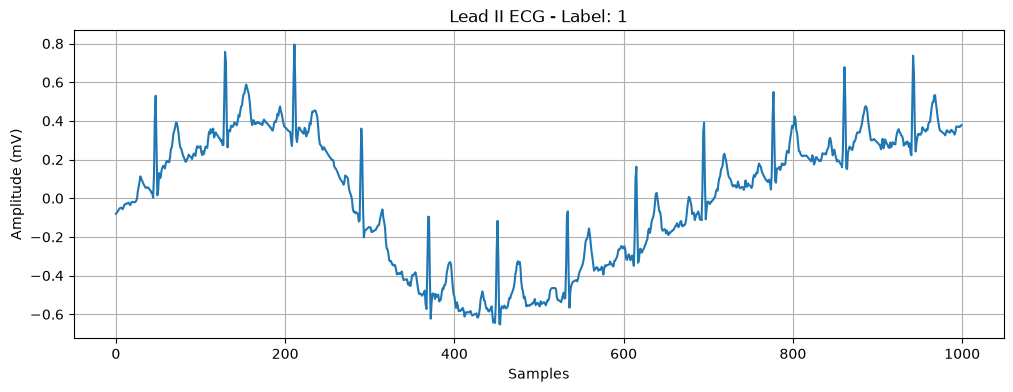

In [ ]:
#visualize the ECG
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(lead_II)

plt.title(
    f"Lead II ECG - Label: {sample['label']}"
)

plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")

plt.grid()
plt.show()